In [19]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

In [ ]:
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "evaluation").exists():
    if (REPO_ROOT.parent / "evaluation").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError("Run this notebook from the repo root or evaluation directory.")

EXPERIMENT_DIR = REPO_ROOT / "experiments/test"
TASKS = ["countdown", "gsm8k", "proofwriter", "hellaswag", "mmlu-pro", "arc-challenge", "piqa"]
TASK_LABELS = {
    "countdown": "Countdown",
    "gsm8k": "GSM8K",
    "proofwriter": "ProofWriter",
    "hellaswag": "HellaSwag",
    "mmlu-pro": "MMLU-Pro",
    "arc-challenge": "ARC-Challenge",
    "piqa": "PIQA",
}

# Set to None to average all non-main tasks, or set e.g. ["gsm8k", "proofwriter"].
PRIOR_TASKS = None

# "last" uses the final main-task evaluation step. Set an integer, e.g. 500, for a fixed step.
SUMMARY_STEP = "last"
ALLOW_PREVIOUS_STEP_FALLBACK = True

# Use "linear" if you include weight_decay_lambda=0 baselines in either panel.
X_SCALE = "log"
OUTPUT_PATH = None  # e.g. REPO_ROOT / "weight_decay_accuracy.pdf"

# Set to None or [] to hide baseline-run reference lines. Baselines are summarized at SUMMARY_STEP.
# Each item can be a Path/string or a dict with path/label overrides.
BASELINE_RUNS = [
    {
        "label": "No weight decay baseline",
        "path": EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed1_popsize30_msFalse_20260328_123119",
    },
]

# Add or remove runs from either list. Each item can be a Path/string or a dict with path/label overrides.
RUN_GROUPS = {
    "l1": [
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.0001_20260428_205632",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.0003_20260424_092222",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.0005_20260428_125032",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.001_20260325_210540",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.003_20260424_034505",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.005_20260429_132302",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.007_20260424_110526",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.01_20260320_201242",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.013_20260423_221044",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.02_20260422_231335",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.03_20260423_042530",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.05_20260411_070812",
    ],
    "l2": [
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd0.05_20260322_084927",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd0.1_20260322_132605",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd0.3_20260424_145300",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd1.0_20260323_140300",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd3.0_20260417_235958",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd5.0_20260324_114329",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd7.0_20260418_051644",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd10.0_20260421_151321",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd15.0_20260423_100641",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd20.0_20260423_154319",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd30.0_20260424_202508",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd50.0_20260424_062818",
        EXPERIMENT_DIR / "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd100.0_20260425_020654",
    ],
}

In [21]:
def resolve_path(path):
    path = Path(path)
    return path if path.is_absolute() else REPO_ROOT / path


def normalize_run_config(config):
    if isinstance(config, (str, Path)):
        return {"path": config}
    return dict(config)


def normalize_run_configs(configs):
    if configs is None:
        return []
    if isinstance(configs, (str, Path)):
        return [configs]
    if isinstance(configs, dict):
        return [configs]
    return list(configs)


def read_run_args(run_dir):
    args_path = run_dir / "args.json"
    if not args_path.is_file():
        return {}
    return json.loads(args_path.read_text())


def infer_train_task(identifier):
    for task in TASKS:
        if task in identifier:
            return task
    raise ValueError(f"Could not infer train task from identifier: {identifier}")


def infer_decay_from_name(name):
    match = re.search(r"_(l[12])wd([0-9.]+)_", name)
    if not match:
        return "none", 0.0
    return match.group(1), float(match.group(2))


def load_metrics(run_dir, task_name):
    path = run_dir / f"{task_name}.jsonl"
    empty_frame = pd.DataFrame(columns=["step", "accuracy"])
    if not path.is_file():
        print(f"Missing metrics file for {task_name}: {path}")
        return empty_frame, path, False

    records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    if not records:
        print(f"No records found in {path}")
        return empty_frame, path, False

    frame = pd.DataFrame(records).sort_values("step").reset_index(drop=True)
    return frame, path, True


def select_metric_row(frame, step):
    if frame.empty:
        return None
    if step == "last":
        return frame.iloc[-1]

    exact = frame[frame["step"] == step]
    if not exact.empty:
        return exact.iloc[-1]

    if ALLOW_PREVIOUS_STEP_FALLBACK:
        previous = frame[frame["step"] <= step]
        if not previous.empty:
            return previous.iloc[-1]
    return None


def prior_tasks_for(train_task):
    if PRIOR_TASKS is not None:
        return list(PRIOR_TASKS)
    return [task for task in TASKS if task != train_task]


def summarize_run(config, expected_decay_type):
    config = normalize_run_config(config)
    run_dir = resolve_path(config["path"])
    run_args = read_run_args(run_dir)

    train_task = config.get("train_task") or run_args.get("task") or infer_train_task(run_dir.name)
    inferred_decay_type, inferred_lambda = infer_decay_from_name(run_dir.name)
    decay_type = config.get("decay_type") or run_args.get("weight_decay_type") or inferred_decay_type
    decay_lambda = float(config.get("weight_decay_lambda", run_args.get("weight_decay_lambda", inferred_lambda)))

    if expected_decay_type is not None and decay_type != expected_decay_type:
        print(f"Warning: {run_dir.name} is configured under {expected_decay_type}, but args say {decay_type}.")

    main_df, main_path, main_available = load_metrics(run_dir, train_task)
    main_row = select_metric_row(main_df, SUMMARY_STEP)
    if main_row is None:
        raise ValueError(f"No main-task accuracy for {run_dir}")

    base_main_rows = main_df[main_df["step"] == 0]
    base_main_accuracy = None
    base_main_step = None
    if not base_main_rows.empty and "accuracy" in base_main_rows:
        base_main_row = base_main_rows.iloc[-1]
        base_main_accuracy = float(base_main_row["accuracy"])
        base_main_step = int(base_main_row["step"])

    selected_step = int(main_row["step"])
    prior_values = []
    prior_steps = []
    base_prior_values = []
    base_prior_steps = []
    missing_prior_tasks = []
    for task_name in prior_tasks_for(train_task):
        prior_df, prior_path, prior_available = load_metrics(run_dir, task_name)
        if not prior_available:
            missing_prior_tasks.append(task_name)
            continue

        base_prior_rows = prior_df[prior_df["step"] == 0]
        if not base_prior_rows.empty and "accuracy" in base_prior_rows:
            base_prior_row = base_prior_rows.iloc[-1]
            base_prior_values.append(float(base_prior_row["accuracy"]))
            base_prior_steps.append(int(base_prior_row["step"]))

        prior_row = select_metric_row(prior_df, selected_step)
        if prior_row is None or "accuracy" not in prior_row:
            missing_prior_tasks.append(task_name)
            continue

        prior_values.append(float(prior_row["accuracy"]))
        prior_steps.append(int(prior_row["step"]))

    if not prior_values:
        raise ValueError(f"No prior-task accuracies for {run_dir}")

    label = config.get("label") or f"seed {run_args.get('global_seed', '?')}"
    return {
        "decay_type": expected_decay_type or decay_type,
        "weight_decay_lambda": decay_lambda,
        "run": run_dir.name,
        "label": label,
        "model_name": run_args.get("model_name"),
        "train_task": train_task,
        "step": selected_step,
        "seed": run_args.get("global_seed"),
        "main_accuracy": float(main_row["accuracy"]),
        "base_main_accuracy": base_main_accuracy,
        "prior_accuracy": sum(prior_values) / len(prior_values),
        "base_prior_accuracy": sum(base_prior_values) / len(base_prior_values) if base_prior_values else None,
        "base_main_step": base_main_step,
        "num_prior_tasks": len(prior_values),
        "num_base_prior_tasks": len(base_prior_values),
        "prior_steps": sorted(set(prior_steps)),
        "base_prior_steps": sorted(set(base_prior_steps)),
        "missing_prior_tasks": missing_prior_tasks,
        "main_metrics_path": main_path,
    }

In [ ]:
records = []
for decay_type, run_configs in RUN_GROUPS.items():
    for run_config in run_configs:
        records.append(summarize_run(run_config, decay_type))

baseline_records = [summarize_run(run_config, None) for run_config in normalize_run_configs(BASELINE_RUNS)]
baseline_df = pd.DataFrame(baseline_records)
if not baseline_df.empty:
    baseline_df = baseline_df.sort_values(["seed", "run"], na_position="last").reset_index(drop=True)


results_df = pd.DataFrame(records).sort_values(
    ["decay_type", "weight_decay_lambda", "seed", "run"],
    na_position="last",
).reset_index(drop=True)

display_columns = [
    "decay_type",
    "weight_decay_lambda",
    "label",
    "train_task",
    "step",
    "main_accuracy",
    "base_main_accuracy",
    "prior_accuracy",
    "base_prior_accuracy",
    "num_prior_tasks",
    "num_base_prior_tasks",
    "missing_prior_tasks",
    "run",
]
display(results_df[display_columns])
if not baseline_df.empty:
    display(baseline_df[display_columns])

In [ ]:
plot_df = results_df.melt(
    id_vars=["decay_type", "weight_decay_lambda", "run", "label", "seed", "train_task", "step"],
    value_vars=["main_accuracy", "prior_accuracy"],
    var_name="metric",
    value_name="accuracy",
)
plot_df["metric"] = plot_df["metric"].map(
    {
        "main_accuracy": "Target task accuracy",
        "prior_accuracy": "Average prior task accuracy",
    }
)

summary_df = (
    plot_df.groupby(["decay_type", "weight_decay_lambda", "metric"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        num_runs=("accuracy", "count"),
    )
    .sort_values(["decay_type", "weight_decay_lambda", "metric"])
)
summary_df["std_accuracy"] = summary_df["std_accuracy"].fillna(0.0)

base_prior_df = (
    results_df.groupby("decay_type", as_index=False)
    .agg(
        base_prior_accuracy=("base_prior_accuracy", "mean"),
        std_base_prior_accuracy=("base_prior_accuracy", "std"),
        num_base_runs=("base_prior_accuracy", "count"),
    )
)
base_prior_df["std_base_prior_accuracy"] = base_prior_df["std_base_prior_accuracy"].fillna(0.0)

baseline_summary_df = pd.DataFrame(columns=["metric", "mean_accuracy", "std_accuracy", "num_runs"])
if not baseline_df.empty:
    baseline_plot_df = baseline_df.melt(
        id_vars=["run", "label", "seed", "train_task", "step"],
        value_vars=["main_accuracy", "prior_accuracy"],
        var_name="metric",
        value_name="accuracy",
    )
    baseline_plot_df["metric"] = baseline_plot_df["metric"].map(
        {
            "main_accuracy": "Target task accuracy",
            "prior_accuracy": "Average prior task accuracy",
        }
    )
    baseline_summary_df = (
        baseline_plot_df.groupby("metric", as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            num_runs=("accuracy", "count"),
        )
        .sort_values("metric")
    )
    baseline_summary_df["std_accuracy"] = baseline_summary_df["std_accuracy"].fillna(0.0)

display(summary_df)
display(base_prior_df)
display(baseline_summary_df)

/tmp/ipykernel_667826/1914948927.py:154: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


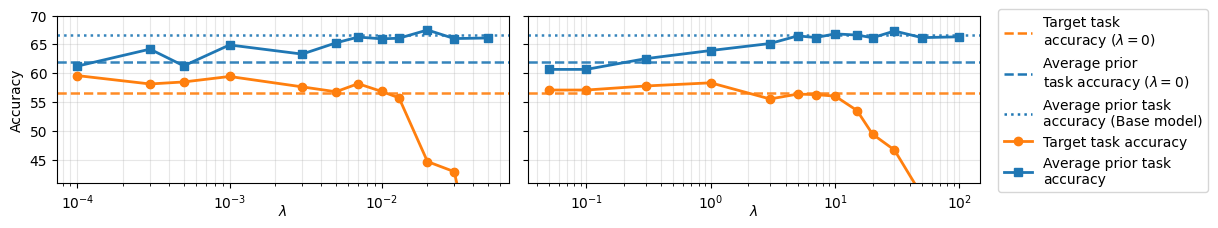

In [27]:
METRIC_STYLES = {
    "Target task accuracy": {"color": "C1", "marker": "o"},
    "Average prior task accuracy": {"color": "C0", "marker": "s"},
}
PANEL_TITLES = {"l1": "$\\ell_1$ Decay", "l2": "$\\ell_2$ Decay"}
BASELINE_LINE_STYLES = {
    "task": {"color": "C1", "linestyle": "--", "label": "Target task\naccuracy ($\\lambda=0$)"},
    "prior": {"color": "C0", "linestyle": "--", "label": "Average prior\ntask accuracy ($\\lambda=0$)"},
}

fig, axes = plt.subplots(1, 2, figsize=(10, 2.4), sharey=True, constrained_layout=True)

for ax, decay_type in zip(axes, ["l1", "l2"]):
    panel_summary = summary_df[summary_df["decay_type"] == decay_type]
    panel_points = plot_df[plot_df["decay_type"] == decay_type]

    # ax.set_title(PANEL_TITLES.get(decay_type, decay_type.upper()))
    ax.set_xlabel("$\\lambda$")
    # make xlabel closer to the x-axis
    ax.xaxis.set_label_coords(0.5, -0.12)
    ax.grid(alpha=0.3, which='both')

    base_prior_row = base_prior_df[base_prior_df["decay_type"] == decay_type]
    if not base_prior_row.empty and pd.notna(base_prior_row.iloc[0]["base_prior_accuracy"]):
        ax.axhline(
            base_prior_row.iloc[0]["base_prior_accuracy"],
            color="C0",
            linestyle=":",
            linewidth=1.8,
            alpha=0.9,
        )

    for metric, baseline_style_key in [
        ("Target task accuracy", "task"),
        ("Average prior task accuracy", "prior"),
    ]:
        baseline_row = baseline_summary_df[baseline_summary_df["metric"] == metric]
        if baseline_row.empty:
            continue

        baseline_mean = baseline_row.iloc[0]["mean_accuracy"]
        baseline_std = baseline_row.iloc[0]["std_accuracy"]
        baseline_num_runs = baseline_row.iloc[0]["num_runs"]
        baseline_style = BASELINE_LINE_STYLES[baseline_style_key]
        if baseline_num_runs > 1:
            ax.axhspan(
                baseline_mean - baseline_std,
                baseline_mean + baseline_std,
                color=baseline_style["color"],
                alpha=0.10,
                linewidth=0,
            )
        ax.axhline(
            baseline_mean,
            color=baseline_style["color"],
            linestyle=baseline_style["linestyle"],
            linewidth=1.8,
            alpha=0.9,
        )

    plotted_any = False
    for metric, style in METRIC_STYLES.items():
        metric_summary = panel_summary[panel_summary["metric"] == metric].sort_values("weight_decay_lambda")
        metric_points = panel_points[panel_points["metric"] == metric]
        if metric_summary.empty:
            continue

        x = metric_summary["weight_decay_lambda"].to_numpy(dtype=float)
        y = metric_summary["mean_accuracy"].to_numpy(dtype=float)
        yerr = metric_summary["std_accuracy"].to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            color=style["color"],
            marker=style["marker"],
            linewidth=2,
            markersize=6,
            label=metric,
        )

        if (metric_summary["num_runs"] > 1).any():
            ax.fill_between(x, y - yerr, y + yerr, color=style["color"], alpha=0.14, linewidth=0)

        ax.scatter(
            metric_points["weight_decay_lambda"],
            metric_points["accuracy"],
            color=style["color"],
            marker=style["marker"],
            s=32,
            edgecolors="black",
            linewidths=0.5,
            alpha=0.75,
        )
        plotted_any = True

    if X_SCALE == "log" and (panel_points["weight_decay_lambda"] > 0).all():
        ax.set_xscale("log")
    elif X_SCALE == "log":
        ax.text(
            0.5,
            0.05,
            "Using linear x-scale because this panel includes lambda=0",
            ha="center",
            va="bottom",
            transform=ax.transAxes,
            color="0.35",
            fontsize=8,
        )

    if not plotted_any:
        ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes, color="0.4")

axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(41, 70)

baseline_reference_handles = []
if not baseline_summary_df.empty:
    baseline_reference_handles = [
        Line2D(
            [0],
            [0],
            color=BASELINE_LINE_STYLES["task"]["color"],
            linestyle=BASELINE_LINE_STYLES["task"]["linestyle"],
            linewidth=1.8,
            label=BASELINE_LINE_STYLES["task"]["label"],
        ),
        Line2D(
            [0],
            [0],
            color=BASELINE_LINE_STYLES["prior"]["color"],
            linestyle=BASELINE_LINE_STYLES["prior"]["linestyle"],
            linewidth=1.8,
            label=BASELINE_LINE_STYLES["prior"]["label"],
        ),
    ]

legend_handles = baseline_reference_handles + [
    Line2D([0], [0], color="C0", linestyle=":", linewidth=1.8, label="Average prior task\naccuracy (Base model)"),
] + [
    Line2D(
        [0],
        [0],
        color=style["color"],
        marker=style["marker"],
        linewidth=2,
        markersize=6,
        label=metric.replace("prior task accuracy", "prior task\naccuracy"),
    )
    for metric, style in METRIC_STYLES.items()
]
fig.legend(handles=legend_handles, loc="center right", bbox_to_anchor=(1.22, 0.56))

plt.tight_layout()

plt.savefig("ablation_lambda.pdf", bbox_inches="tight")
plt.show()